# h1_v2_allow Outlier EDA

`data_h1_v2_allow`의 휴먼(ALLOW) trial만 대상으로 한 EDA입니다.

목적은 다음 두 가지입니다.
1. feature 자체의 품질 문제를 먼저 정리한다.
2. 모델 학습 전에 제외 검토할 outlier trial의 범위를 좁힐 수 있는 기준선을 만든다.

`eda_template`의 큰 섹션 구조를 따르되, `eda_chan`처럼 실제 판단에 도움이 되는 표와 셀 흐름 위주로 구성합니다.

In [15]:
import json
import platform
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

In [16]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1200)

system = platform.system()
if system == "Darwin":
    font_candidates = ["Nanum Gothic", "AppleGothic"]
elif system == "Windows":
    font_candidates = ["Malgun Gothic"]
else:
    font_candidates = ["Nanum Gothic", "DejaVu Sans"]

for font_name in font_candidates:
    try:
        plt.rcParams["font.family"] = font_name
        print(f"한글 폰트 적용: {font_name}")
        break
    except Exception:
        continue

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", context="notebook")

한글 폰트 적용: Malgun Gothic


## 1. 데이터 로드

In [17]:
ROOT = Path.cwd()
if ROOT.name != "EDA":
    raise RuntimeError("작업 디렉토리를 services/ai/train/EDA 로 맞춘 뒤 실행하세요.")

DATA_DIR = ROOT.parent.parent / "data" / "data_h1_v2_allow"
FEATURE_CONFIG_PATH = ROOT.parent.parent / "configs" / "feature_config.yaml"

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("FEATURE_CONFIG_PATH:", FEATURE_CONFIG_PATH)

if not DATA_DIR.exists():
    raise FileNotFoundError(DATA_DIR)
if not FEATURE_CONFIG_PATH.exists():
    raise FileNotFoundError(FEATURE_CONFIG_PATH)

ROOT: c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\EDA
DATA_DIR: c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow
FEATURE_CONFIG_PATH: c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\configs\feature_config.yaml


In [18]:
with open(FEATURE_CONFIG_PATH, "r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_GROUPS = feature_config["groups"]
FEATURE_NAME_KR = feature_config.get("names_ko", {})
EXCLUDE_COL = set(feature_config.get("exclude", [])) | {"trial_id", "label"}
FEATURE_GROUP_MAP = {
    feature: group
    for group, features in FEATURE_GROUPS.items()
    for feature in features
}


def load_allow_trials(data_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(data_dir.glob("trial_*.json")):
        payload = json.loads(path.read_text(encoding="utf-8"))
        trial_id = payload.get("trialID") or payload.get("trialId") or payload.get("trial_id")
        label = payload.get("label")
        feature_values = payload.get("features") or payload.get("metrics") or {}

        row = {
            "trial_id": int(trial_id),
            "label": label,
            "path": str(path),
        }
        if isinstance(feature_values, dict):
            row.update(feature_values)
        rows.append(row)

    frame = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)
    return frame


df = load_allow_trials(DATA_DIR)
print("trial 수:", len(df))
print("label 분포:")
print(df["label"].value_counts(dropna=False).to_string())
display(df.head())

trial 수: 30
label 분포:
label
ALLOW    30


,trial_id,label,path,reclick_rate,misclick_rate,mouse_jerk_mean,double_click_rate,mouse_overshoot_flag,mousemove_event_rate,pre_click_scroll_flag,time_to_first_click_ms,inter_click_interval_ms,mouse_acceleration_mean,mouse_speed_change_mean,pre_click_hover_time_ms,click_offset_variance_px,mouse_stop_segment_count,mouse_avg_speed_px_per_ms,mouse_hover_dwell_time_ms,mouse_max_speed_px_per_ms,mouse_path_curvature_mean,pre_click_mousemove_count,click_position_repeat_rate,mouse_direction_change_count,mouse_path_straightness_score,edge_or_fixed_point_visit_rate,mouse_total_travel_distance_px,click_sequence_consistency_score,immediate_post_render_click_rate,pre_click_path_300ms_straightness,pre_click_path_500ms_straightness,inter_element_move_interval_std_ms,click_offset_from_element_center_px,time_from_element_visible_to_click_ms,pre_click_path_300ms_total_distance_px,pre_click_path_500ms_total_distance_px,time_from_element_clickable_to_click_ms
0,690,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00690.json,0,0.000000,0.000185,0.285714,0,7.112835,0,6847,858.714286,0.010878,0.605931,172.714286,NaN,10.0,0.274939,172.714286,3.971109,0.057248,6.142857,0,21.0,0.141173,0.022727,3401.551199,0.0,0,1.00,0.12,NaN,50.331402,12287.000000,43,83,12379.000000
1,691,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00691.json,0,0.000000,0.000088,0.000000,0,13.381078,0,1692,509.500000,0.004700,0.280515,126.666667,9.401328,11.0,0.311655,126.666667,2.275434,0.072963,6.333333,0,26.0,0.093224,0.000000,1653.641413,1.0,0,1.00,1.00,9.5,11.453471,2178.333333,12,179,2186.333333
2,692,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00692.json,0,0.000000,0.000208,0.000000,0,10.097684,0,2711,1383.600000,0.010979,0.582735,169.800000,0.041177,13.0,0.386061,169.800000,10.080972,0.073135,6.400000,0,26.0,0.153864,0.000000,3517.400582,0.0,0,0.98,0.98,1619.0,10.891699,1961.000000,43,554,1970.000000
3,693,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00693.json,0,0.000000,0.000105,0.000000,1,10.654040,0,2601,776.000000,0.006606,0.388131,294.000000,NaN,5.0,0.268303,294.000000,2.657707,0.128139,5.000000,0,16.0,0.435865,0.027778,906.594965,0.0,0,1.00,0.48,NaN,15.206906,3337.000000,12,44,3377.000000
4,694,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00694.json,0,0.333333,0.000093,0.000000,0,10.235732,0,1630,1102.500000,0.004701,0.271625,180.666667,1076.325487,16.0,0.171093,180.666667,2.268127,0.159361,5.333333,0,30.0,0.024390,0.000000,1103.206819,1.0,0,1.00,1.00,438.5,35.678068,4196.666667,3,50,4216.000000


## 2. 데이터 전처리

In [19]:
meta_cols = [c for c in ["trial_id", "label", "path"] if c in df.columns]
raw_feature_cols = [c for c in df.columns if c not in meta_cols and c not in EXCLUDE_COL]

numeric_df = df.copy()
for col in raw_feature_cols:
    numeric_df[col] = pd.to_numeric(numeric_df[col], errors="coerce")

all_null_cols = [c for c in raw_feature_cols if numeric_df[c].notna().sum() == 0]
mostly_null_cols = [c for c in raw_feature_cols if numeric_df[c].isna().mean() >= 0.95]
constant_cols = []
for col in raw_feature_cols:
    valid = numeric_df[col].dropna()
    if len(valid) > 0 and valid.nunique() <= 1:
        constant_cols.append(col)

analysis_feature_cols = [
    c for c in raw_feature_cols
    if c not in set(all_null_cols)
]

print("원본 feature 수:", len(raw_feature_cols))
print("전부 null feature 수:", len(all_null_cols))
print("95% 이상 null feature 수:", len(mostly_null_cols))
print("상수 feature 수:", len(constant_cols))
print("분석 대상 feature 수:", len(analysis_feature_cols))

if all_null_cols:
    print("\n[all-null feature]")
    print(all_null_cols)

if mostly_null_cols:
    print("\n[95%+ null feature]")
    print(mostly_null_cols)

if constant_cols:
    print("\n[constant feature]")
    print(constant_cols)

원본 feature 수: 34
전부 null feature 수: 0
95% 이상 null feature 수: 0
상수 feature 수: 4
분석 대상 feature 수: 34

[constant feature]
['reclick_rate', 'pre_click_scroll_flag', 'click_position_repeat_rate', 'immediate_post_render_click_rate']


In [20]:
def feature_quality_summary(frame: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    rows = []
    for feature in feature_cols:
        s = pd.to_numeric(frame[feature], errors="coerce")
        valid = s.dropna()
        q01 = valid.quantile(0.01) if len(valid) else np.nan
        q05 = valid.quantile(0.05) if len(valid) else np.nan
        q25 = valid.quantile(0.25) if len(valid) else np.nan
        q50 = valid.quantile(0.50) if len(valid) else np.nan
        q75 = valid.quantile(0.75) if len(valid) else np.nan
        q95 = valid.quantile(0.95) if len(valid) else np.nan
        q99 = valid.quantile(0.99) if len(valid) else np.nan
        iqr = q75 - q25 if pd.notna(q75) and pd.notna(q25) else np.nan
        lower = q25 - 1.5 * iqr if pd.notna(iqr) else np.nan
        upper = q75 + 1.5 * iqr if pd.notna(iqr) else np.nan
        iqr_outlier_ratio = float(((valid < lower) | (valid > upper)).mean()) if len(valid) and pd.notna(lower) else np.nan
        median = valid.median() if len(valid) else np.nan
        mad = (valid - median).abs().median() if len(valid) else np.nan
        robust_scale = mad * 1.4826 if pd.notna(mad) else np.nan
        if pd.notna(robust_scale) and robust_scale > 1e-12:
            robust_z = (valid - median) / robust_scale
            robust_outlier_ratio = float((robust_z.abs() >= 3.5).mean())
        else:
            robust_outlier_ratio = np.nan
        rows.append(
            {
                "group": FEATURE_GROUP_MAP.get(feature, "other"),
                "feature": feature,
                "feature_ko": FEATURE_NAME_KR.get(feature, feature),
                "count": int(valid.shape[0]),
                "null_ratio": float(s.isna().mean()),
                "zero_ratio": float((valid == 0).mean()) if len(valid) else np.nan,
                "n_unique": int(valid.nunique()) if len(valid) else 0,
                "mean": float(valid.mean()) if len(valid) else np.nan,
                "std": float(valid.std()) if len(valid) else np.nan,
                "min": float(valid.min()) if len(valid) else np.nan,
                "q01": float(q01) if pd.notna(q01) else np.nan,
                "q05": float(q05) if pd.notna(q05) else np.nan,
                "q25": float(q25) if pd.notna(q25) else np.nan,
                "median": float(q50) if pd.notna(q50) else np.nan,
                "q75": float(q75) if pd.notna(q75) else np.nan,
                "q95": float(q95) if pd.notna(q95) else np.nan,
                "q99": float(q99) if pd.notna(q99) else np.nan,
                "max": float(valid.max()) if len(valid) else np.nan,
                "iqr": float(iqr) if pd.notna(iqr) else np.nan,
                "iqr_outlier_ratio": iqr_outlier_ratio,
                "robust_outlier_ratio": robust_outlier_ratio,
                "skew": float(valid.skew()) if len(valid) > 2 else np.nan,
            }
        )
    return pd.DataFrame(rows)


def robust_zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    median = s.median()
    mad = (s - median).abs().median()
    scale = mad * 1.4826
    if pd.isna(scale) or scale <= 1e-12:
        return pd.Series(np.nan, index=s.index)
    return (s - median) / scale


def iqr_bounds(series: pd.Series) -> tuple[float, float]:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return (np.nan, np.nan)
    q25 = s.quantile(0.25)
    q75 = s.quantile(0.75)
    iqr = q75 - q25
    return (q25 - 1.5 * iqr, q75 + 1.5 * iqr)


def percentile_rank(series: pd.Series, value: float) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0 or pd.isna(value):
        return np.nan
    return float((s <= value).mean())


def top_feature_list(summary_df: pd.DataFrame, top_n: int = 12) -> list[str]:
    cols = summary_df.sort_values(
        ["iqr_outlier_ratio", "robust_outlier_ratio", "null_ratio"],
        ascending=[False, False, True],
    )["feature"].tolist()
    return cols[:top_n]

## 3. 기본 분석

In [21]:
feature_summary_df = feature_quality_summary(numeric_df, analysis_feature_cols)
feature_summary_df = feature_summary_df.sort_values(
    ["null_ratio", "iqr_outlier_ratio", "robust_outlier_ratio"],
    ascending=[False, False, False],
).reset_index(drop=True)

candidate_drop_df = feature_summary_df[
    (feature_summary_df["null_ratio"] >= 0.95)
    | (feature_summary_df["n_unique"] <= 1)
    | (feature_summary_df["zero_ratio"] >= 0.98)
].copy()

print("feature quality summary")
display(feature_summary_df)

print("\n모델 학습 전 제외 검토가 필요한 feature 후보")
display(candidate_drop_df[[
    "group", "feature", "null_ratio", "zero_ratio", "n_unique", "iqr_outlier_ratio", "robust_outlier_ratio"
]].sort_values(["null_ratio", "zero_ratio", "n_unique"], ascending=[False, False, True]))

feature quality summary


,group,feature,feature_ko,count,null_ratio,zero_ratio,n_unique,mean,std,min,q01,q05,q25,median,q75,q95,q99,max,iqr,iqr_outlier_ratio,robust_outlier_ratio,skew
0,other,click_offset_variance_px,click_offset_variance_px,18,0.400000,0.000000,18,167.375149,364.671296,0.041177,0.267037,1.170480,9.757443,27.502507,80.651566,1099.152467,1202.634779,1228.505356,70.894123,0.166667,0.166667,2.595843
1,other,inter_element_move_interval_std_ms,inter_element_move_interval_std_ms,18,0.400000,0.000000,18,688.004303,662.423490,9.500000,10.350000,13.750000,95.125000,355.197370,1334.856886,1627.325000,1665.065000,1674.500000,1239.731886,0.000000,0.000000,0.421603
2,other,inter_click_interval_ms,inter_click_interval_ms,21,0.300000,0.000000,21,1002.312698,398.021973,449.500000,461.500000,509.500000,720.000000,875.000000,1218.333333,1542.800000,1941.893333,2041.666667,498.333333,0.047619,0.000000,0.822253
3,mouse,mouse_jerk_mean,저크 평균,26,0.133333,0.000000,26,0.000142,0.000087,0.000045,0.000046,0.000050,0.000089,0.000113,0.000184,0.000239,0.000407,0.000461,0.000094,0.038462,0.038462,2.026458
4,mouse,edge_or_fixed_point_visit_rate,고정점 방문률,28,0.066667,0.750000,8,0.027544,0.115742,0.000000,0.000000,0.000000,0.000000,0.000000,0.004386,0.032842,0.458132,0.615385,0.004386,0.250000,NaN,5.214224
5,mouse,mouse_speed_change_mean,속도 변화,28,0.066667,0.000000,28,0.503297,0.366977,0.024382,0.047431,0.126599,0.278713,0.400504,0.583485,1.339388,1.519862,1.577423,0.304772,0.107143,0.107143,1.678345
6,mouse,mouse_acceleration_mean,가속도 변화,28,0.066667,0.000000,28,0.008157,0.005547,0.000056,0.000094,0.000953,0.004859,0.006904,0.009821,0.017938,0.023336,0.025218,0.004962,0.107143,0.035714,1.246396
7,mouse,mouse_avg_speed_px_per_ms,평균 속도,28,0.066667,0.000000,28,0.281411,0.176894,0.035093,0.040489,0.057498,0.197581,0.268758,0.312746,0.518566,0.872336,0.981149,0.115166,0.071429,0.071429,2.369079
8,mouse,mouse_path_straightness_score,경로 직선성,28,0.066667,0.000000,28,0.252856,0.224325,0.024390,0.025523,0.034473,0.108624,0.179828,0.289285,0.651613,0.915118,0.984129,0.180661,0.071429,0.071429,1.751195
9,mouse,mouse_hover_dwell_time_ms,평균 dwell,28,0.066667,0.000000,27,254.200170,165.352593,34.333333,34.693333,61.450000,157.500000,182.916667,340.583333,586.650000,638.960000,653.000000,183.083333,0.035714,0.107143,1.057823



모델 학습 전 제외 검토가 필요한 feature 후보


,group,feature,null_ratio,zero_ratio,n_unique,iqr_outlier_ratio,robust_outlier_ratio
30,click,reclick_rate,0.0,1.0,1,0.0,NaN
31,click,pre_click_scroll_flag,0.0,1.0,1,0.0,NaN
32,click,click_position_repeat_rate,0.0,1.0,1,0.0,NaN
33,click,immediate_post_render_click_rate,0.0,1.0,1,0.0,NaN


`comment`
- 여기서는 먼저 feature 자체를 걸러냅니다.
- `null_ratio`가 매우 높거나, 거의 항상 0이거나, 사실상 상수인 feature는 trial outlier보다도 feature 설계 문제일 가능성이 큽니다.
- 표본 수가 30건이라 `v1`보다 변동성이 커 보일 수 있으므로, 단일 수치보다 여러 지표를 함께 해석하는 것이 중요합니다.

### 3-1 데이터 분포 시각화

분포 확인 우선순위 feature:
['edge_or_fixed_point_visit_rate', 'misclick_rate', 'mouse_overshoot_flag', 'click_offset_variance_px', 'double_click_rate', 'time_from_element_visible_to_click_ms', 'time_from_element_clickable_to_click_ms', 'mousemove_event_rate', 'mouse_speed_change_mean', 'mouse_acceleration_mean', 'mouse_avg_speed_px_per_ms', 'mouse_path_straightness_score']


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:19: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:19: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:19: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:19: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:19: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:19: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) Arial.
  plt.tight_la

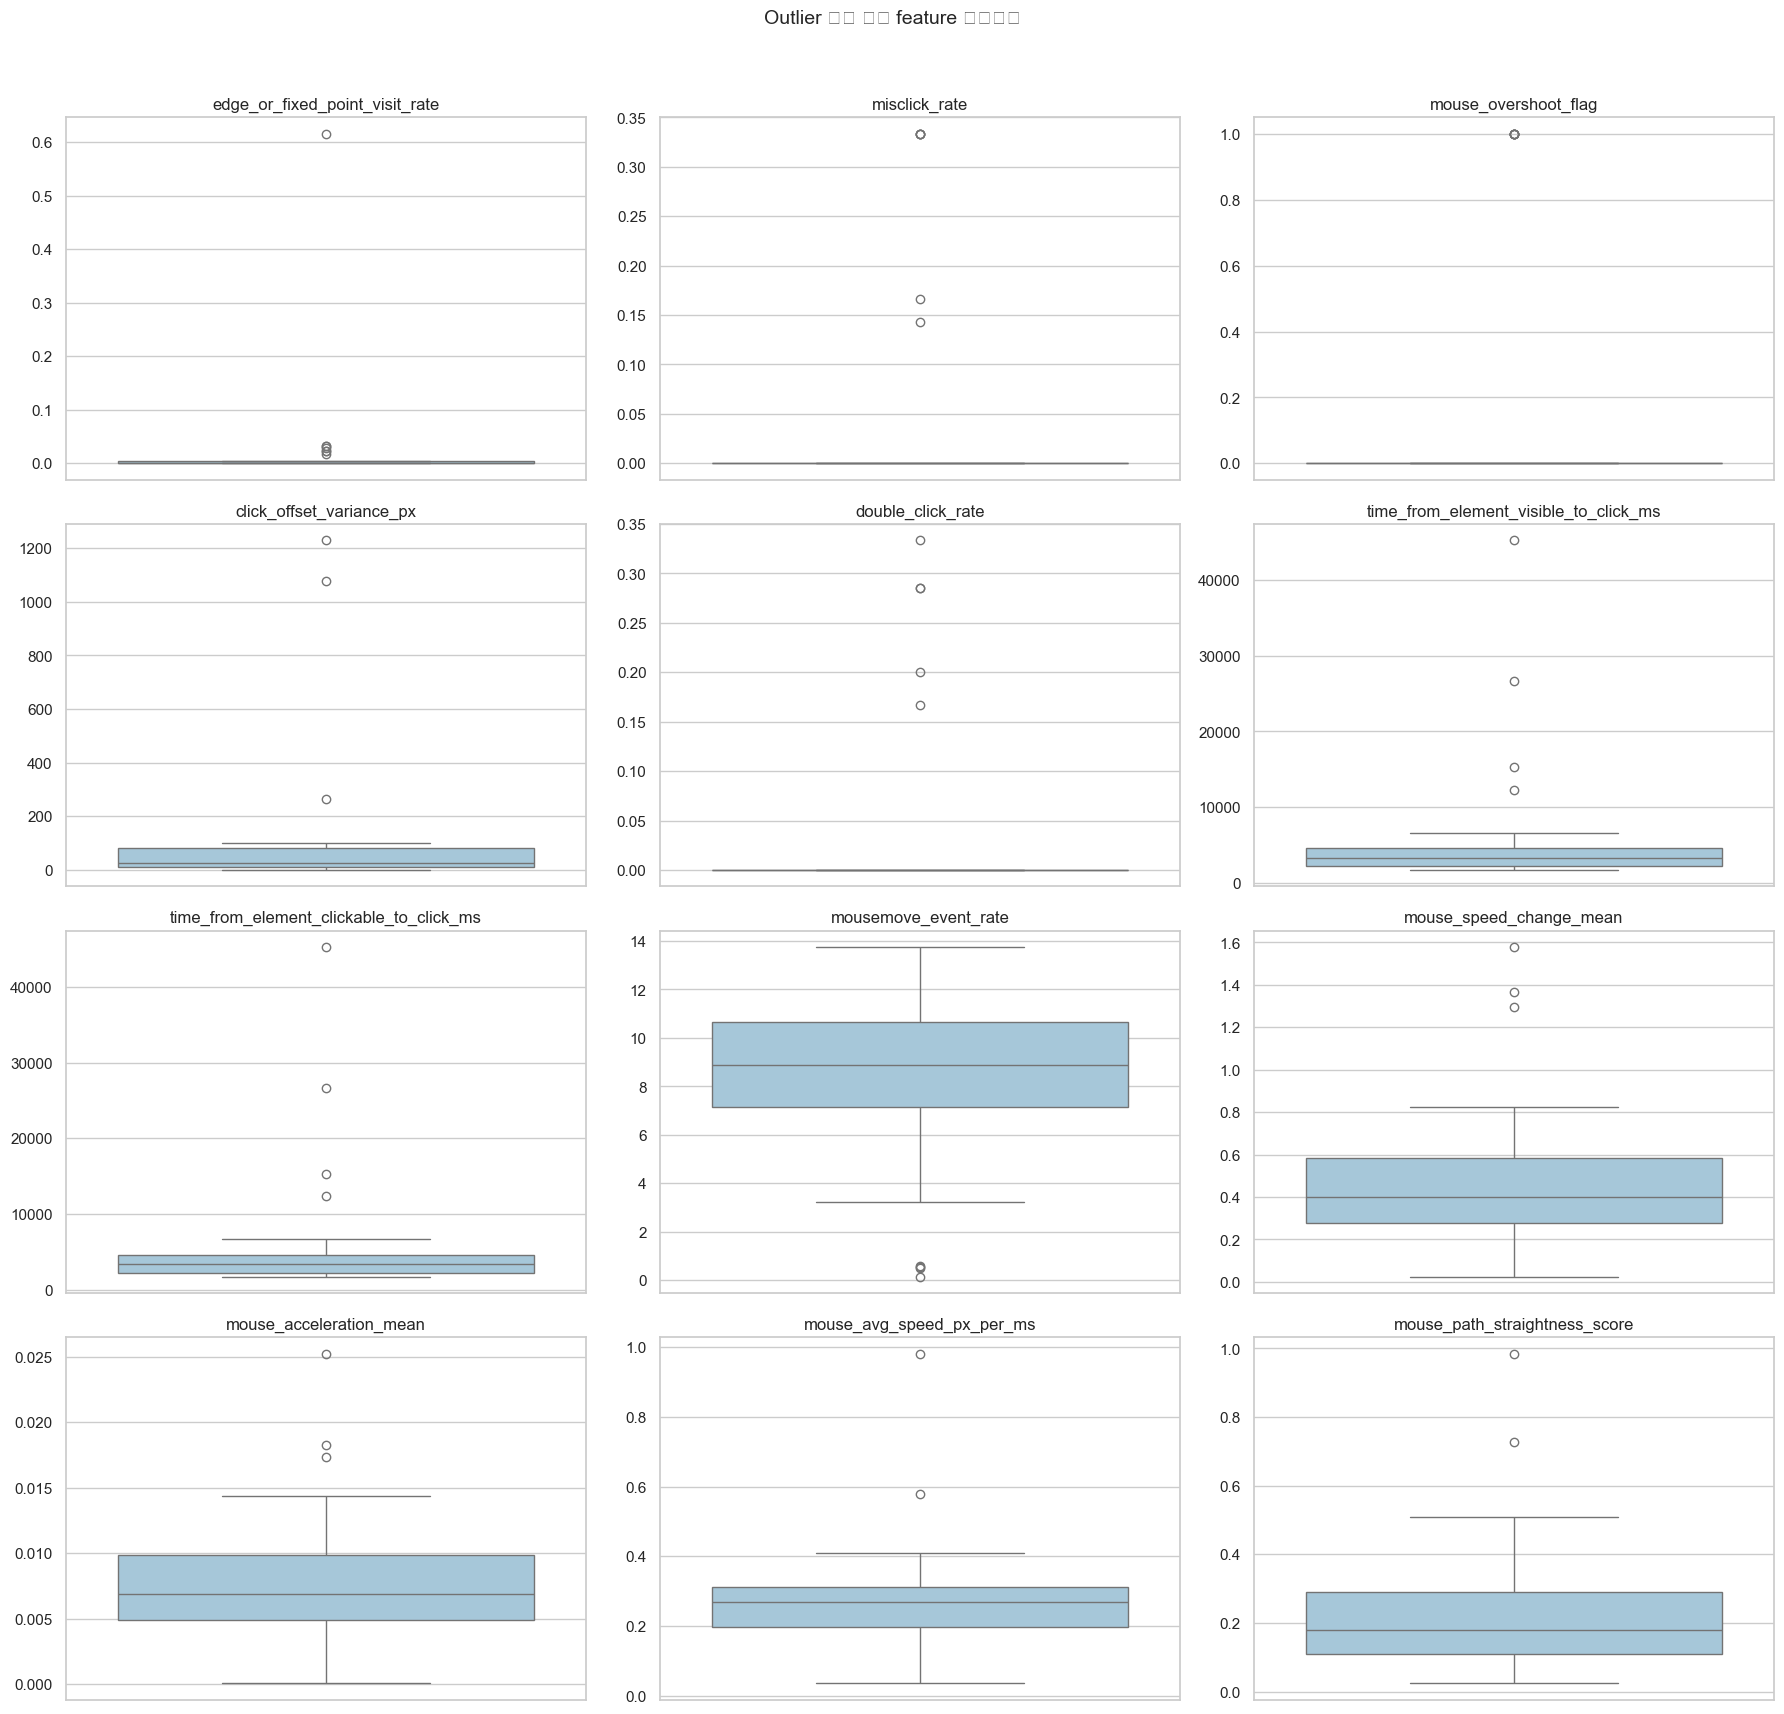

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:40: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:40: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:40: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:40: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:40: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25588\2111460854.py:40: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) Arial.
  plt.t

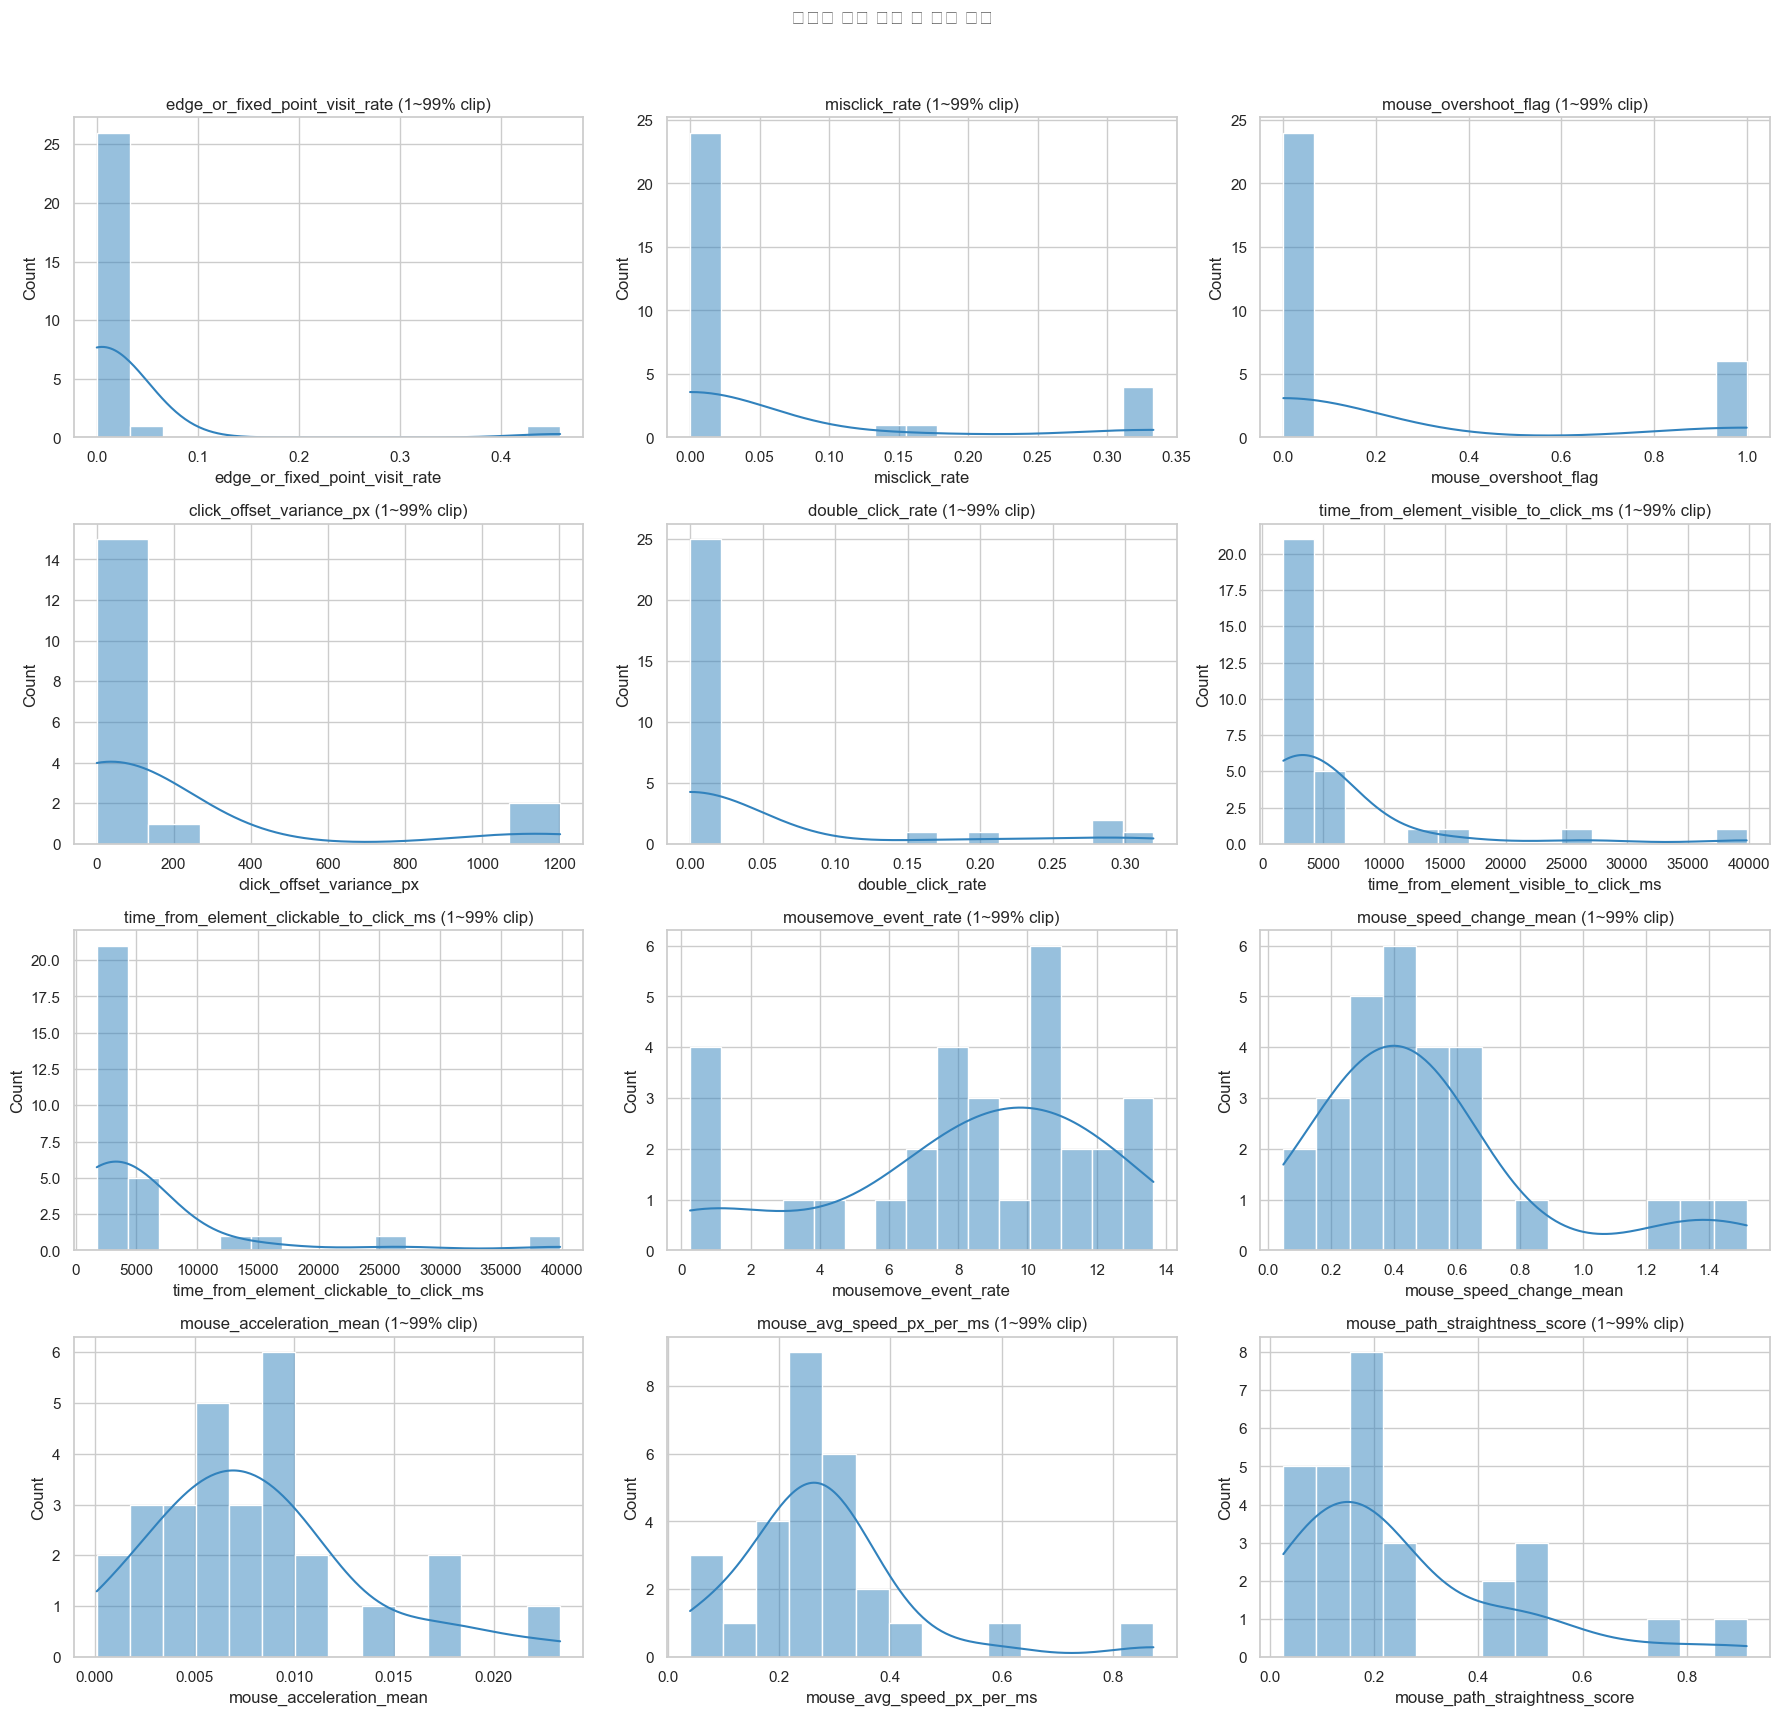

In [22]:
focus_features = top_feature_list(feature_summary_df, top_n=12)
print("분포 확인 우선순위 feature:")
print(focus_features)

ncols = 3
nrows = int(np.ceil(len(focus_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, focus_features):
    sns.boxplot(y=numeric_df[feature], ax=ax, color="#9ecae1")
    ax.set_title(feature)
    ax.set_ylabel("")

for ax in axes[len(focus_features):]:
    ax.axis("off")

fig.suptitle("Outlier 우선 검토 feature 박스플롯", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, focus_features):
    s = pd.to_numeric(numeric_df[feature], errors="coerce").dropna()
    if len(s) == 0:
        ax.axis("off")
        continue
    low = s.quantile(0.01)
    high = s.quantile(0.99)
    clipped = s.clip(lower=low, upper=high)
    sns.histplot(clipped, bins=min(20, max(8, len(s) // 2)), kde=True, ax=ax, color="#3182bd")
    ax.set_title(f"{feature} (1~99% clip)")

for ax in axes[len(focus_features):]:
    ax.axis("off")

fig.suptitle("극단값 영향 완화 후 분포 확인", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 3-2 상관관계 분석

c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Ari

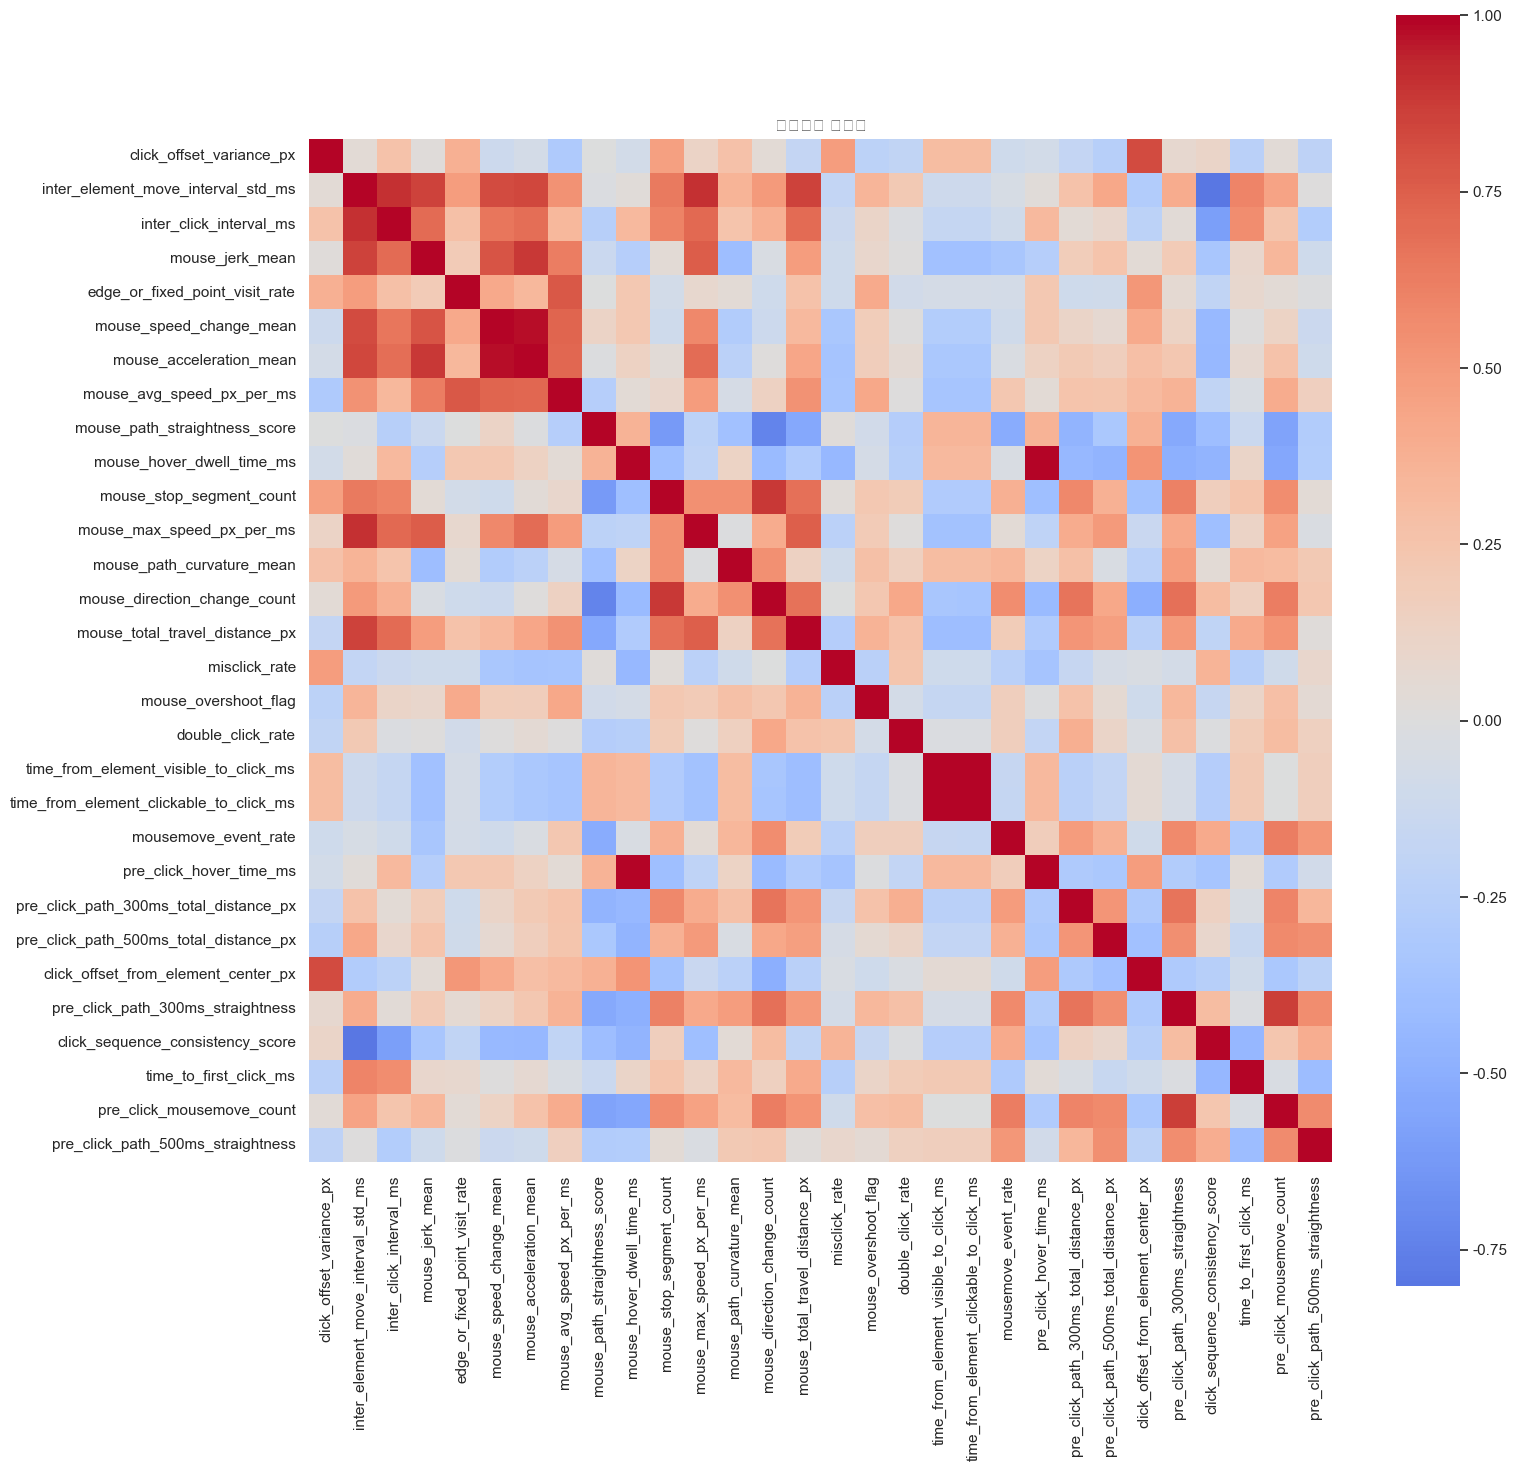

|corr| >= 0.90 pair


,feature_a,feature_b,corr
0,mouse_hover_dwell_time_ms,pre_click_hover_time_ms,1.000000
1,time_from_element_visible_to_click_ms,time_from_element_clickable_to_click_ms,0.999998
2,mouse_speed_change_mean,mouse_acceleration_mean,0.978512
3,inter_element_move_interval_std_ms,mouse_max_speed_px_per_ms,0.907683
4,inter_element_move_interval_std_ms,inter_click_interval_ms,0.903692


In [23]:
corr_feature_cols = feature_summary_df.loc[
    (feature_summary_df["null_ratio"] < 0.50) & (feature_summary_df["n_unique"] > 1),
    "feature",
].tolist()

corr_df = numeric_df[corr_feature_cols].corr()
side = max(10, min(18, 0.55 * len(corr_feature_cols)))
plt.figure(figsize=(side, side))
sns.heatmap(corr_df, cmap="coolwarm", center=0, square=True)
plt.title("상관관계 히트맵")
plt.show()

high_corr_pairs = []
for i, left in enumerate(corr_feature_cols):
    for right in corr_feature_cols[i + 1:]:
        value = corr_df.loc[left, right]
        if pd.notna(value) and abs(value) >= 0.90:
            high_corr_pairs.append((left, right, float(value)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["feature_a", "feature_b", "corr"])
if not high_corr_df.empty:
    high_corr_df = high_corr_df.sort_values("corr", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print("|corr| >= 0.90 pair")
display(high_corr_df)

### 3-3 PCA

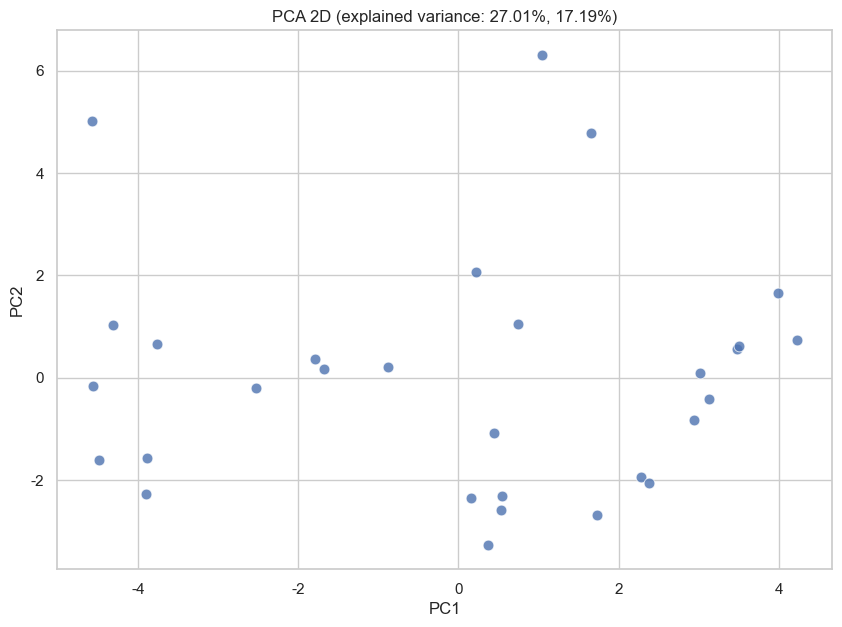

,count,mean,std,min,25%,50%,75%,max
trial_id,30.0,7.045000e+02,8.803408,690.000000,697.250000,704.500000,711.750000,719.000000
PC1,30.0,0.000000e+00,2.895244,-4.568351,-2.341278,0.489008,2.351594,4.227812
PC2,30.0,1.702342e-16,2.309462,-3.265080,-1.855776,-0.031141,0.724163,6.309115


In [24]:
pca_feature_cols = feature_summary_df.loc[
    (feature_summary_df["null_ratio"] < 0.80) & (feature_summary_df["n_unique"] > 1),
    "feature",
].tolist()

pca_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42)),
])

pca_coords = pca_pipe.fit_transform(numeric_df[pca_feature_cols])
pca_model = pca_pipe.named_steps["pca"]

pca_df = pd.DataFrame({
    "trial_id": numeric_df["trial_id"],
    "PC1": pca_coords[:, 0],
    "PC2": pca_coords[:, 1],
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=60, alpha=0.8)
plt.title(
    f"PCA 2D (explained variance: {pca_model.explained_variance_ratio_[0]:.2%}, {pca_model.explained_variance_ratio_[1]:.2%})"
)
plt.show()

display(pca_df.describe().T)

## 4. Personal EDA

이 섹션은 **어떤 trial을 학습 전 outlier 후보로 먼저 검토할지**를 정하는 데 초점을 둡니다.

단일 기준 하나만 쓰지 않고 아래 네 축을 함께 봅니다.
- feature-wise robust z-score 이상치 개수
- IQR 기준 이상치 개수
- 1% / 99% 극단 percentile 개수
- IsolationForest raw score 기반 rank

이 네 가지를 trial-level로 합쳐서 `composite_score`를 만듭니다.

In [25]:
trial_scores = numeric_df[["trial_id", "label", "path"]].copy()
robust_flag_cols = []
iqr_flag_cols = []
extreme_flag_cols = []

for feature in analysis_feature_cols:
    s = pd.to_numeric(numeric_df[feature], errors="coerce")

    rz = robust_zscore(s)
    robust_flag = rz.abs() >= 3.5
    robust_flag_cols.append(robust_flag.rename(feature))

    lower, upper = iqr_bounds(s)
    iqr_flag = (s < lower) | (s > upper)
    iqr_flag_cols.append(iqr_flag.rename(feature))

    valid = s.dropna()
    if len(valid):
        low_q = valid.quantile(0.01)
        high_q = valid.quantile(0.99)
        extreme_flag = (s <= low_q) | (s >= high_q)
    else:
        extreme_flag = pd.Series(False, index=s.index)
    extreme_flag_cols.append(extreme_flag.rename(feature))

robust_flag_df = pd.concat(robust_flag_cols, axis=1).fillna(False)
iqr_flag_df = pd.concat(iqr_flag_cols, axis=1).fillna(False)
extreme_flag_df = pd.concat(extreme_flag_cols, axis=1).fillna(False)

trial_scores["robust_outlier_count"] = robust_flag_df.sum(axis=1)
trial_scores["iqr_outlier_count"] = iqr_flag_df.sum(axis=1)
trial_scores["extreme_1pct_count"] = extreme_flag_df.sum(axis=1)

iforest_features = feature_summary_df.loc[
    (feature_summary_df["null_ratio"] < 0.80) & (feature_summary_df["n_unique"] > 1),
    "feature",
].tolist()

iforest_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    (
        "iforest",
        IsolationForest(
            n_estimators=300,
            contamination="auto",
            max_features=1.0,
            random_state=42,
        ),
    ),
])
iforest_pipe.fit(numeric_df[iforest_features])
raw_decision = pd.Series(iforest_pipe.decision_function(numeric_df[iforest_features]), index=numeric_df.index)
trial_scores["iforest_outlier_score"] = (-raw_decision).rank(pct=True)

for col in ["robust_outlier_count", "iqr_outlier_count", "extreme_1pct_count"]:
    trial_scores[f"{col}_rank"] = trial_scores[col].rank(method="average", pct=True)

trial_scores["composite_score"] = trial_scores[[
    "robust_outlier_count_rank",
    "iqr_outlier_count_rank",
    "extreme_1pct_count_rank",
    "iforest_outlier_score",
]].mean(axis=1)

trial_scores = trial_scores.sort_values(
    ["composite_score", "iforest_outlier_score", "robust_outlier_count"],
    ascending=[False, False, False],
).reset_index(drop=True)

print("상위 outlier 의심 trial")
display(trial_scores.head(30))

상위 outlier 의심 trial


,trial_id,label,path,robust_outlier_count,iqr_outlier_count,extreme_1pct_count,iforest_outlier_score,robust_outlier_count_rank,iqr_outlier_count_rank,extreme_1pct_count_rank,composite_score
0,704,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00704.json,6,4,20,0.900000,1.000000,0.916667,1.000000,0.954167
1,698,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00698.json,4,4,13,0.800000,0.916667,0.916667,0.750000,0.845833
2,717,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00717.json,2,3,15,0.933333,0.700000,0.800000,0.933333,0.841667
3,710,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00710.json,4,3,14,0.766667,0.916667,0.800000,0.850000,0.833333
4,707,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00707.json,5,4,14,0.600000,0.966667,0.916667,0.850000,0.833333
5,701,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00701.json,3,6,11,1.000000,0.833333,1.000000,0.466667,0.825000
6,713,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00713.json,2,2,15,0.966667,0.700000,0.583333,0.933333,0.795833
7,700,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00700.json,2,1,15,0.733333,0.700000,0.316667,0.933333,0.670833
8,697,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00697.json,1,2,13,0.866667,0.466667,0.583333,0.750000,0.666667
9,690,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v2_allow\trial_00690.json,3,4,8,0.700000,0.833333,0.916667,0.116667,0.641667


In [26]:
candidate_rates = [0.01, 0.02, 0.03, 0.05, 0.075, 0.10]
rows = []
for rate in candidate_rates:
    threshold = trial_scores["composite_score"].quantile(1.0 - rate)
    selected = trial_scores[trial_scores["composite_score"] >= threshold]
    rows.append(
        {
            "rate": rate,
            "threshold": float(threshold),
            "flagged_trials": int(len(selected)),
            "trial_ids_preview": selected["trial_id"].head(10).tolist(),
        }
    )

contamination_sweep_df = pd.DataFrame(rows)
display(contamination_sweep_df)

,rate,threshold,flagged_trials,trial_ids_preview
0,0.010,0.922750,1,[704]
1,0.020,0.891333,1,[704]
2,0.030,0.859917,1,[704]
3,0.050,0.843958,2,"[704, 698]"
4,0.075,0.840208,3,"[704, 698, 717]"
5,0.100,0.834167,3,"[704, 698, 717]"


In [27]:
def explain_trial(trial_id: int, top_n: int = 10) -> pd.DataFrame:
    row = numeric_df.loc[numeric_df["trial_id"] == trial_id]
    if row.empty:
        raise ValueError(f"trial_id {trial_id} not found")
    row = row.iloc[0]

    explain_rows = []
    for feature in analysis_feature_cols:
        series = pd.to_numeric(numeric_df[feature], errors="coerce")
        value = pd.to_numeric(pd.Series([row[feature]]), errors="coerce").iloc[0]
        if pd.isna(value):
            continue

        rz = robust_zscore(series).loc[row.name]
        lower, upper = iqr_bounds(series)
        pct = percentile_rank(series, value)

        tags = []
        if pd.notna(rz) and abs(rz) >= 3.5:
            tags.append("robust_z")
        if pd.notna(lower) and (value < lower or value > upper):
            tags.append("iqr")
        if pd.notna(pct) and (pct <= 0.01 or pct >= 0.99):
            tags.append("p01/p99")
        elif pd.notna(pct) and (pct <= 0.05 or pct >= 0.95):
            tags.append("p05/p95")

        if not tags:
            continue

        explain_rows.append(
            {
                "feature": feature,
                "feature_ko": FEATURE_NAME_KR.get(feature, feature),
                "value": value,
                "robust_z": float(rz) if pd.notna(rz) else np.nan,
                "percentile": pct,
                "iqr_lower": lower,
                "iqr_upper": upper,
                "tags": ", ".join(tags),
                "extremeness": max(abs((pct or 0) - 0.5), abs(rz) / 10 if pd.notna(rz) else 0),
            }
        )

    explain_df = pd.DataFrame(explain_rows)
    if explain_df.empty:
        return explain_df
    return explain_df.sort_values(["extremeness", "percentile"], ascending=[False, True]).head(top_n)

for _, suspicious in trial_scores.head(10).iterrows():
    trial_id = int(suspicious["trial_id"])
    print(f"\n=== trial_id {trial_id} | composite={suspicious['composite_score']:.4f} | iforest_rank={suspicious['iforest_outlier_score']:.4f} ===")
    display(explain_trial(trial_id, top_n=12))


=== trial_id 704 | composite=0.9542 | iforest_rank=0.9000 ===


,feature,feature_ko,value,robust_z,percentile,iqr_lower,iqr_upper,tags,extremeness
12,pre_click_path_300ms_straightness,300ms 경로 직선성,0.000000,-18.596674,0.333333,-1.500000,2.500000,robust_z,1.859667
10,mouse_path_straightness_score,경로 직선성,0.984129,7.078374,1.000000,-0.162367,0.560276,"robust_z, iqr, p01/p99",0.707837
0,reclick_rate,재클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
1,pre_click_scroll_flag,클릭 전 스크롤,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
8,click_position_repeat_rate,좌표 반복률,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
11,immediate_post_render_click_rate,즉시 클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
3,mouse_speed_change_mean,속도 변화,1.364232,4.819107,0.964286,-0.178445,1.040643,"robust_z, iqr, p05/p95",0.481911
7,pre_click_mousemove_count,클릭 전 이동 수,0.000000,-3.744587,0.033333,-2.910714,11.517857,"robust_z, p05/p95",0.466667
14,time_from_element_visible_to_click_ms,노출 후 클릭,1698.000000,-0.951919,0.033333,-1194.666667,8004.666667,p05/p95,0.466667
15,time_from_element_clickable_to_click_ms,활성 후 클릭,1725.000000,-0.950829,0.033333,-1198.541667,8025.791667,p05/p95,0.466667



=== trial_id 698 | composite=0.8458 | iforest_rank=0.8000 ===


,feature,feature_ko,value,robust_z,percentile,iqr_lower,iqr_upper,tags,extremeness
4,mouse_speed_change_mean,속도 변화,1.577423,5.885166,1.000000,-0.178445,1.040643,"robust_z, iqr, p01/p99",0.588517
0,reclick_rate,재클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
1,mouse_jerk_mean,저크 평균,0.000461,4.312641,1.000000,-0.000052,0.000325,"robust_z, iqr, p01/p99",0.500000
2,pre_click_scroll_flag,클릭 전 스크롤,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
3,mouse_acceleration_mean,가속도 변화,0.025218,4.447511,1.000000,-0.002584,0.017264,"robust_z, iqr, p01/p99",0.500000
6,pre_click_mousemove_count,클릭 전 이동 수,7.000000,1.139657,1.000000,-2.910714,11.517857,p01/p99,0.500000
7,click_position_repeat_rate,좌표 반복률,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
8,immediate_post_render_click_rate,즉시 클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
5,mouse_avg_speed_px_per_ms,평균 속도,0.578138,3.789433,0.964286,0.024832,0.485495,"robust_z, iqr, p05/p95",0.464286



=== trial_id 717 | composite=0.8417 | iforest_rank=0.9333 ===


...

,feature,feature_ko,value,robust_z,percentile,iqr_lower,iqr_upper,tags,extremeness
7,pre_click_path_300ms_straightness,300ms 경로 직선성,0.000000,-18.596674,0.333333,-1.500000,2.500000,robust_z,1.859667
0,reclick_rate,재클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
1,pre_click_scroll_flag,클릭 전 스크롤,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
2,time_to_first_click_ms,첫 클릭 시간,7236.000000,4.195151,1.000000,-1598.000000,7266.000000,"robust_z, p01/p99",0.500000
3,inter_click_interval_ms,inter_click_interval_ms,2041.666667,3.260660,1.000000,-27.500000,1965.833333,"iqr, p01/p99",0.500000
4,click_position_repeat_rate,좌표 반복률,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
6,immediate_post_render_click_rate,즉시 클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
5,mouse_total_travel_distance_px,총 이동 거리,3632.533894,1.091140,0.964286,-2731.224795,6881.417591,p05/p95,0.464286



=== trial_id 697 | composite=0.6667 | iforest_rank=0.8667 ===


,feature,feature_ko,value,robust_z,percentile,iqr_lower,iqr_upper,tags,extremeness
7,pre_click_path_300ms_straightness,300ms 경로 직선성,0.000000,-18.596674,0.333333,-1.500000,2.500000,robust_z,1.859667
0,reclick_rate,재클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
1,misclick_rate,오클릭 비율,0.333333,NaN,1.000000,0.000000,0.000000,"iqr, p01/p99",0.500000
3,pre_click_scroll_flag,클릭 전 스크롤,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
5,click_position_repeat_rate,좌표 반복률,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
6,immediate_post_render_click_rate,즉시 클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
4,mouse_max_speed_px_per_ms,최대 속도,0.319907,-0.850618,0.035714,-4.832466,12.720038,p05/p95,0.464286
2,mousemove_event_rate,mousemove 빈도,0.494315,-3.160592,0.066667,1.852589,15.961450,iqr,0.433333



=== trial_id 690 | composite=0.6417 | iforest_rank=0.7000 ===


,feature,feature_ko,value,robust_z,percentile,iqr_lower,iqr_upper,tags,extremeness
9,time_from_element_clickable_to_click_ms,활성 후 클릭,12379.000000,5.235132,0.900000,-1198.541667,8025.791667,"robust_z, iqr",0.523513
8,time_from_element_visible_to_click_ms,노출 후 클릭,12287.000000,5.185735,0.900000,-1194.666667,8004.666667,"robust_z, iqr",0.518573
0,reclick_rate,재클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
2,pre_click_scroll_flag,클릭 전 스크롤,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
4,click_position_repeat_rate,좌표 반복률,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
6,immediate_post_render_click_rate,즉시 클릭 비율,0.000000,NaN,1.000000,0.000000,0.000000,p01/p99,0.500000
7,pre_click_path_300ms_straightness,300ms 경로 직선성,1.000000,0.674491,1.000000,-1.500000,2.500000,p01/p99,0.500000
1,double_click_rate,더블클릭 비율,0.285714,NaN,0.966667,0.000000,0.000000,"iqr, p05/p95",0.466667
3,time_to_first_click_ms,첫 클릭 시간,6847.000000,3.858986,0.966667,-1598.000000,7266.000000,"robust_z, p05/p95",0.466667
5,edge_or_fixed_point_visit_rate,고정점 방문률,0.022727,NaN,0.857143,-0.006579,0.010965,iqr,0.357143


## 5. 분석 리포트

In [28]:
drop_candidates = candidate_drop_df["feature"].tolist()
review_top_1pct = contamination_sweep_df.loc[contamination_sweep_df["rate"] == 0.01, "flagged_trials"].iloc[0]
review_top_3pct = contamination_sweep_df.loc[contamination_sweep_df["rate"] == 0.03, "flagged_trials"].iloc[0]
review_top_5pct = contamination_sweep_df.loc[contamination_sweep_df["rate"] == 0.05, "flagged_trials"].iloc[0]

print("[요약]")
print(f"- 전체 trial 수: {len(df)}")
print(f"- 분석 대상 feature 수: {len(analysis_feature_cols)}")
print(f"- 즉시 제외 검토 feature 수: {len(drop_candidates)}")
print(f"- 1% review line: 상위 {review_top_1pct}개 trial")
print(f"- 3% review line: 상위 {review_top_3pct}개 trial")
print(f"- 5% review line: 상위 {review_top_5pct}개 trial")

print("\n[권장 해석 순서]")
print("1. all-null / 95%+ null / 상수 feature를 먼저 학습 풀에서 제거 검토")
print("2. composite_score 상위 1~2건부터 수동 검토")
print("3. 표본 수가 작으므로 3% 이상은 자동 제거보다 수동 확인 우선")
print("4. 제거 전후로 feature별 분포와 상관관계가 얼마나 안정화되는지 재확인")

print("\n[즉시 제외 검토 feature 목록]")
print(drop_candidates)

print("\n[가장 먼저 볼 outlier 의심 trial_id]")
print(trial_scores.head(20)["trial_id"].tolist())

[요약]
- 전체 trial 수: 30
- 분석 대상 feature 수: 34
- 즉시 제외 검토 feature 수: 4
- 1% review line: 상위 1개 trial
- 3% review line: 상위 1개 trial
- 5% review line: 상위 2개 trial

[권장 해석 순서]
1. all-null / 95%+ null / 상수 feature를 먼저 학습 풀에서 제거 검토
2. composite_score 상위 1~2건부터 수동 검토
3. 표본 수가 작으므로 3% 이상은 자동 제거보다 수동 확인 우선
4. 제거 전후로 feature별 분포와 상관관계가 얼마나 안정화되는지 재확인

[즉시 제외 검토 feature 목록]
['reclick_rate', 'pre_click_scroll_flag', 'click_position_repeat_rate', 'immediate_post_render_click_rate']

[가장 먼저 볼 outlier 의심 trial_id]
[704, 698, 717, 710, 707, 701, 713, 700, 697, 690, 694, 718, 695, 696, 692, 711, 716, 715, 702, 705]
